# CMSC320 Programming Assignment 6
Please go through the file following the instructions as you go.

Rename this notebook to `CMSC320_PA6_YourName.ipynb`

Note that there may be quite a few things for you to do yourself/look up. Welcome to the life of a Data Scientist (again)!

**Each numbered question is worth 2 points to make things easier**, for a total of 50*2= 100 points.

## Part 1. Regression
You will use the California Housing dataset to perform:
- Simple Linear Regression
- Multiple Linear Regression
- Ridge Regression
- Lasso Regression

In [1]:
# Read and run this cell
from sklearn.datasets import fetch_california_housing
import pandas as pd

california = fetch_california_housing()
california_df = pd.DataFrame(california.data,
                             columns=california.feature_names)
california_df['MedHouseValue'] = pd.Series(california.target)
california_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Simple Linear Regression

1. Select **Median Income (`MedInc`)** as the single feature to predict **Median House Value (`MedHouseVal`)**.
2. Train/test split.
3. Fit a simple linear regression model.
4. Plot the regression line on top of the training data.
5. What is the learned coefficient for the independent variable?
6. What is the intercept?
7. Plot a residual scatterplot for the training data.
8. Do you observe heteroskedasticity or any other issues (text response)?
9. Plot a histogram of the residuals for the training data.
10. Does the histogram look approximately normal (text response)?
11. What are the test MSE and R² scores?
12. Based on the plot and the evaluation metrics, does Median Income seem like a strong single predictor? Explain.

In [13]:
# Run this cell
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
# Feel free to import other things here or at any point before you use them

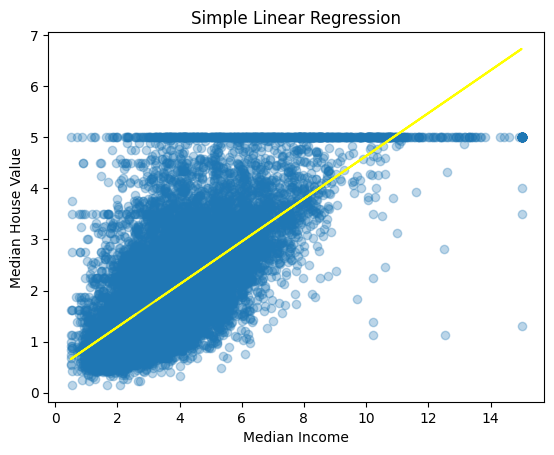

Coefficient: 0.4193384939381274
Intercept: 0.44459729169078677


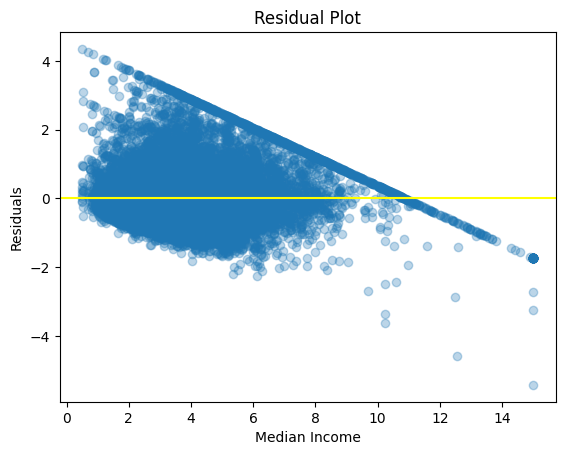

In [47]:
# Answer questions 1-12 starting now and before the Multiple Regression section.
# Feel free to add code/text cells to answer each question. Make sure it's clear which question each cell is answering (for code cells, use #comments).

# 1. selecting feature and target

X = california_df[['MedInc']]
y = california_df['MedHouseValue']

# 2. train/test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. training the model

model = LinearRegression()
model.fit(X_train, y_train)

# 4. plotting regression lien


plt.scatter(X_train, y_train, alpha=0.3)
plt.plot(X_train, model.predict(X_train), color='yellow')
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Simple Linear Regression")
plt.show()



coef = model.coef_[0] # 5. coefficient for the independent variable
intercept = model.intercept_ # 6. intercept

print("Coefficient:", coef)
print("Intercept:", intercept)

# 7. 

residuals = y_train - model.predict(X_train)

plt.scatter(X_train, residuals, alpha=0.3)
plt.axhline(y=0, color='yellow')
plt.xlabel("Median Income")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()






8. The residual plot shows a rather wide range of spread as median icnome increases (not concentrated around the line of best fit), which implies heteroskedasticity. This means that the variance of the errors within the model is not homogeneous or constant, which is usually necessary for linear regression assumptions before reliable use. 

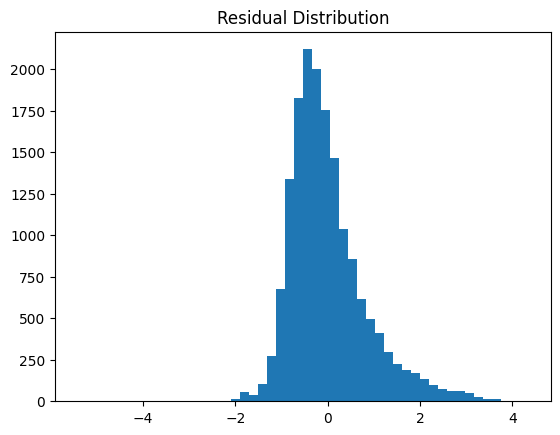

In [8]:
# 9. histogram of residuals for training data

plt.hist(residuals, bins=50)
plt.title("Residual Distribution")
plt.show()

10. The residuals are approximately normally distributed (bell-curve shape), with slight right skew on the right side tail. Therefore, the assumption of normality for linear regression usage is fulfilled here (mild level of outliers). 

In [10]:
# 11. test MSE and R^2 scores

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R²:", r2)

MSE: 0.7091157771765548
R²: 0.45885918903846656


12. The median income is a somewhat strong predictor of hosuing prices, as the R^2 score reveals that there is a positive linear relationship (0.46) between median income and median house value. However, the relationship isn't strong or valid enough to explain housing prices on their own (higher error, and coefficient could be higher). Instead, more features for the model could be included for better performance in the near future (stronger attention to detail with more balanced data).

## Multiple Linear Regression
Use **all 8 features** of the California Housing dataset to predict median housing value.
Train a multiple linear regression model and evaluate performance.

13. Train/test split AGAIN. You need a new split.
14. Fit a multiple linear regression model.
15. Provide a table of coefficients with feature names.
16. What are the test MSE and R² scores?
17. Compare test MSE and R² to those from simple regression. Which are better? Why? (text response)
18. Which features seem most important? Explain. (text response)

In [12]:
# Answer questions 13-18 starting now and before the Ridge & Lasso section.
# Feel free to add code/text cells to answer each question. Make sure it's clear which question each cell is answering.

# 13. train/test split again

X = california_df.drop(columns=['MedHouseValue'])
y = california_df['MedHouseValue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 14. fitting multiple linear regression model 

multi_linear_model = LinearRegression()
multi_linear_model.fit(X_train, y_train)

# 15. table of coefficients with feature names

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": multi_linear_model.coef_
})

print(coefficients)

# 16. test MSE and R^2 scores

y_pred = multi_linear_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R²:", r2)




      Feature  Coefficient
0      MedInc     0.448675
1    HouseAge     0.009724
2    AveRooms    -0.123323
3   AveBedrms     0.783145
4  Population    -0.000002
5    AveOccup    -0.003526
6    Latitude    -0.419792
7   Longitude    -0.433708
MSE: 0.5558915986952444
R²: 0.5757877060324508


17. The MSE is lower (0.56), and the R^2 score (0.58) is higher compared to the simple linear regression, indicating that the multiple regression model is performing better than the simple regression model due to the inclusion of more feature variables for the model to use in its assessment of median house value.

18. Features like median income and average bedrooms seem to be the most important indicators of potential median house value (pricing) as they have stronger positive coefficients that reveal good relationships. Everything else seems to have negligible or negative effects on this same value, due to the lower coefficient values present.

## Ridge & Lasso Regression

You'll be using all features and the algorithm will determine whether to include each one. (If it sets a feature's coefficient to 0 the feature is effectively not included in the model.) Try alphas = [0.01, 0.1, 1, 10, 100].

19. Create a new dataframe for features, where the features are standardized using StandardScaler.
20. Train/test split. (Remember to use the newly created dataset in the X position.)
21. For each alpha, fit a ridge regression model and a lasso regression model.
22. For ridge regression, plot alpha vs test MSE for each alpha.
23. Which alpha performs best? Why? (text response)
24. For lasso regression, plot alpha vs test MSE for each alpha.
25. Which alpha performs best? Why? (text response)
26. For lasso regression, for each alpha, how many coefficients are zero?
27. Which is the best alpha and the best model (ridge or lasso) based on the MSE data? (text response)
28. What is the best model out of simple linear regression, multiple linear regression, ridge regression and lasso regression based on the MSE data? (text response)
29. Why does Lasso set coefficients to zero while Ridge does not?

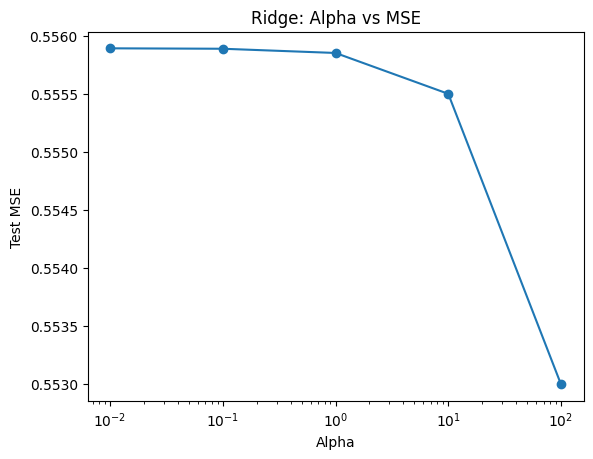

In [ ]:

# Answer questions 19-29 starting now and before the Clustering section.
# Feel free to add code/text cells to answer each question. Make sure it's clear which question each cell is answering.

# 19. new dataframe for features and standardized 

X = california_df.drop(columns=['MedHouseValue'])
y = california_df['MedHouseValue']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 20. train/test split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 21. training ridge and lasso for each alpha 

alphas = [0.01, 0.1, 1, 10, 100]

ridge_mse = []
lasso_mse = []

ridge_models = {}
lasso_models = {}

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    ridge_pred = ridge.predict(X_test)
    ridge_mse.append(mean_squared_error(y_test, ridge_pred))
    ridge_models[alpha] = ridge

    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train, y_train)
    lasso_pred = lasso.predict(X_test)
    lasso_mse.append(mean_squared_error(y_test, lasso_pred))
    lasso_models[alpha] = lasso
    
# 22. plotting alpha vs test MSE for each alpha (ridge)

plt.plot(alphas, ridge_mse, marker='o')
plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("Test MSE")
plt.title("Ridge: Alpha vs MSE")
plt.show()



23. The best alpha in this scenario appears to be 10^2 (100), as here the test MSE remains at its lowest. A larger alpha value here represents a stronger penalty that forces the regression coefficients to shrink more toward zero (lower variance, higher bias, allowing for feature selection).

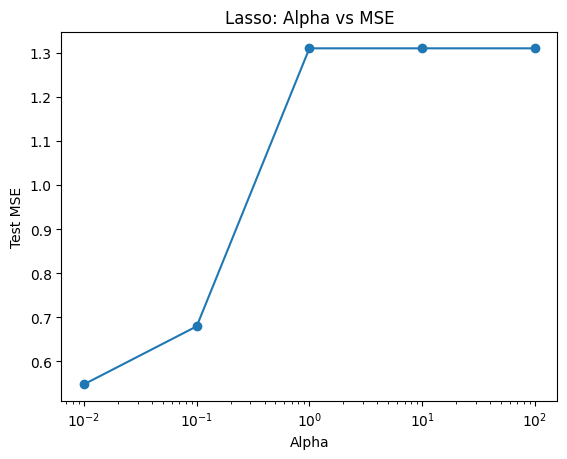

In [ ]:
# 24. plotting the alpha vs test MSE for each alpha (lasso)

plt.plot(alphas, lasso_mse, marker = 'o')
plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("Test MSE")
plt.title("Lasso: Alpha vs MSE")
plt.show()

25. The best alpha in this scenario appears to be 10^-2 (0.01), as the plot test MSE remains at its lowest during this point. A lower alpha value here represents a weaker penalty that allows coefficients to vary freely (higher variance, lower bias)  

In [18]:
# 26. number of zero coefficients for lasso regression

for alpha in alphas:
    model = lasso_models[alpha]
    zero_count = np.sum(model.coef_ == 0)
    print(f"Alpha {alpha}: {zero_count} coefficients are zero")

Alpha 0.01: 1 coefficients are zero
Alpha 0.1: 5 coefficients are zero
Alpha 1: 8 coefficients are zero
Alpha 10: 8 coefficients are zero
Alpha 100: 8 coefficients are zero


27. The model that performed best here was ridge by a slight margin, as it's test MSE was a bit lower (0.5530) than the one represented by the lasso alpha vs MSE plot. With an alpha of 10^2 (100) at this low MSE value, it differs greatly from the lasso model which had an alpha of 0.01 and a test MSE around the same value but higher than 0.5530. This outcome makes sense, as ridge typically performs slightly better due to the retainment of all features while attempting to reduce overfitting during feature selection. On the other hand, lasso tends to remove features that could be important (alpha at 100 removed 8 features where coefficients were set to 0). 

28. The model that performed the best overall was ridge regression based on the MSE, as it's test MSE was the lowest out of them all at 0.5530 with no features removed. 

29. Lasso sets coefficients to zero while ridge does not because it uses L1 regularization which adds a penalty equal to the absolute value of coefficients. The penalty ends up shrinking some coefficients to zero while effectively performing feature selection as necessary. On the other hand, ridge uses L2 regularization, which penalizes based on the square of the coefficients. This ends up shrinking coefficients but never makes them exactly zero, so all features remain in the model. 

## Part 2. Clustering


You will perform clustering analysis on the US Crime dataset using four different clustering algorithms: KMeans, MiniBatchKMeans, DBSCAN, and Gaussian Mixture Models (GMM). We only looked at KMeans but you can use the other ones easily even if you don't necessarily know their inner workings.

The goal is to analyze the clustering performance and explore how crime patterns change over the years.

In [33]:
# Run this cell
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import normalize
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans

1. Import data from "US_crime_data.csv" into df_crimes (this file is bigger than some we've seen before so this will take a bit of time).
2. Display the first few rows.
3. Display the shape of the data
4. Display the data types of each column.
5. Create a new df group the table by year and display it using .head().
6. Using the new df, plot the total number of crimes per year.

For the original df_crimes, handle the missing values:

7. for "Victim Age," use mean,
8. for "Victim Count," use 0,
9. for "Incident," use 0,
10. for "Crime Type," "Weapon," and "Agency Name," use "Unknown."

/var/folders/p3/729vs9tj48x10t6j15pxvm6c0000gn/T/ipykernel_21121/2401717549.py:6: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  df_crimes = pd.read_csv("US_crime_data.csv")


   Record ID Agency Code Agency Name       Agency Type       City   State  \
0          1     AK00101   Anchorage  Municipal Police  Anchorage  Alaska   
1          2     AK00101   Anchorage  Municipal Police  Anchorage  Alaska   
2          3     AK00101   Anchorage  Municipal Police  Anchorage  Alaska   
3          4     AK00101   Anchorage  Municipal Police  Anchorage  Alaska   
4          5     AK00101   Anchorage  Municipal Police  Anchorage  Alaska   

   Year    Month  Incident              Crime Type  ... Victim Ethnicity  \
0  1980  January         1  Murder or Manslaughter  ...          Unknown   
1  1980    March         1  Murder or Manslaughter  ...          Unknown   
2  1980    March         2  Murder or Manslaughter  ...          Unknown   
3  1980    April         1  Murder or Manslaughter  ...          Unknown   
4  1980    April         2  Murder or Manslaughter  ...          Unknown   

  Perpetrator Sex  Perpetrator Age               Perpetrator Race  \
0          

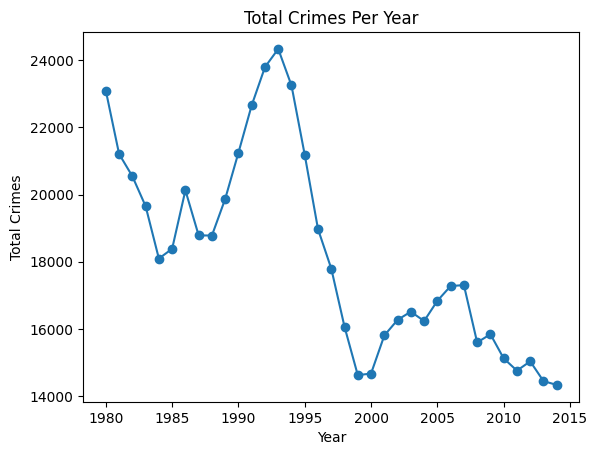

/var/folders/p3/729vs9tj48x10t6j15pxvm6c0000gn/T/ipykernel_21121/2401717549.py:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_crimes["Victim Age"].fillna(df_crimes["Victim Age"].mean(), inplace=True)
/var/folders/p3/729vs9tj48x10t6j15pxvm6c0000gn/T/ipykernel_21121/2401717549.py:40: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on wh

In [ ]:
# Answer questions 1-7 starting now and before the triple horizontal line
# Feel free to add code/text cells to answer each question. Make sure it's clear which question each cell is answering.

# 1. importing data 

df_crimes = pd.read_csv("US_crime_data.csv")

# 2. displaying first few rows

print(df_crimes.head())

# 3. displaying shape of data

print(df_crimes.shape)

# 4. displaying data types

print(df_crimes.dtypes)

# 5. new df grouping by year and display

df_year_group = df_crimes.groupby("Year").size().reset_index(name="Total Crimes")
print(df_year_group.head())

# 6. plotting the total number of crimes per year

plt.plot(df_year_group["Year"], df_year_group["Total Crimes"], marker='o')
plt.xlabel("Year")
plt.ylabel("Total Crimes")
plt.title("Total Crimes Per Year")
plt.show()

# 7. missing vicitm age values handled

df_crimes["Victim Age"].fillna(df_crimes["Victim Age"].mean(), inplace=True)


# 8. missing victim count handled

df_crimes["Victim Count"].fillna(0, inplace=True)

# 9. missing incident handled

df_crimes["Incident"].fillna(0, inplace=True)

# 10. missing crime type, weapon, and agency name handled 

cols = ["Crime Type", "Weapon", "Agency Name"]

for col in cols:
    df_crimes[col].fillna("Unknown", inplace=True)



---

---

---

In [28]:
# READ and run this cell

# Define features for clustering
numeric_features = ['Year', 'Victim Age', 'Victim Count', 'Incident']

# Define features for clustering
categorical_features = ['Crime Type', 'Weapon', 'Agency Name']

# Use ColumnTransformer to standardize numeric features and one-hot encode categorical features:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(), categorical_features)
    ])

# Prepare the data
X = preprocessor.fit_transform(df_crimes)

In [29]:
# Run this cell to see what you're working with now
print(X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4469164 stored elements and shape (638452, 9238)>
  Coords	Values
  (0, 0)	-1.5916238150047646
  (0, 1)	-0.5052687512630585
  (0, 2)	-0.2293592969924127
  (0, 3)	-0.23839282656786398
  (0, 5)	1.0
  (0, 6)	1.0
  (0, 171)	1.0
  (1, 0)	-1.5916238150047646
  (1, 1)	0.19137213702713704
  (1, 2)	-0.2293592969924127
  (1, 3)	-0.23839282656786398
  (1, 5)	1.0
  (1, 19)	1.0
  (1, 171)	1.0
  (2, 0)	-1.5916238150047646
  (2, 1)	-0.12091515772364024
  (2, 2)	-0.2293592969924127
  (2, 3)	-0.22754094144176548
  (2, 5)	1.0
  (2, 21)	1.0
  (2, 171)	1.0
  (3, 0)	-1.5916238150047646
  (3, 1)	0.19137213702713704
  (3, 2)	-0.2293592969924127
  (3, 3)	-0.23839282656786398
  :	:
  (638448, 3)	-0.23839282656786398
  (638448, 5)	1.0
  (638448, 14)	1.0
  (638448, 6920)	1.0
  (638449, 0)	1.8331431811376162
  (638449, 1)	-0.8415781456100493
  (638449, 2)	-0.2293592969924127
  (638449, 3)	-0.23839282656786398
  (638449, 5)	1.0
  (638449, 20)	1.0
  (638

In [30]:
# Read and run this cell

# Take 0.1 of your data to run the clustering on. Otherwise it will be very slow.

df_sample = df_crimes.sample(frac=0.1, random_state=1)
df_sample.shape

(63845, 24)

11. Use preprocessor to transform df_sample into X_sample the same way you transformed df_crimes into X

In [ ]:
# Answer question 8 here
X_sample = preprocessor.transform(df_sample)

12. Use PCA for dimensionality reduction

In [32]:
# Answer question 9 here
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample)

Look up inertia scores in clustering to have an idea what they are.

In [36]:
# Define a range for K (for K-Means) and initialize a list for inertia and silhouette scores
# Read and run this cell

k_values = range(2, 11)
inertia_scores = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=1)
    labels = kmeans.fit_predict(X_pca)
    
    inertia_scores.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, labels))

13. Fit KMeans for different values of k; Use the PCA-reduced data from above.
14. For each k, calculate the inertia score and silhouette score and add them to appropriate lists.

Note that this may take some time to complete.

In [37]:
# Answer questions 9-10 here

for k in k_values:
    print(k)
    # Add your code
    # Use random_state=1 for KMeans

2
3
4
5
6
7
8
9
10


15. Plot silhouette scores and inertia scores vs k. You can use two plots or one plot depending on what makes more sense to you given the values.

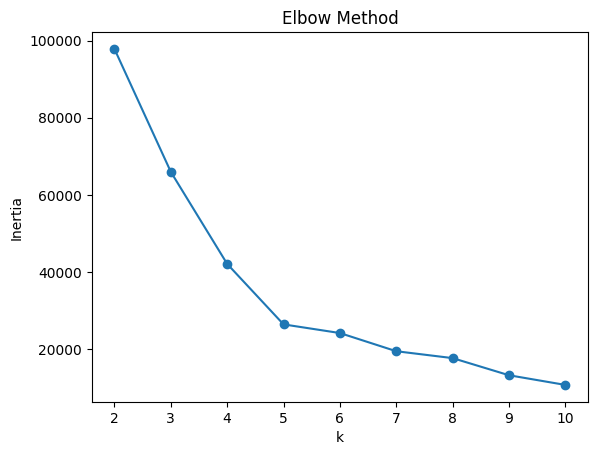

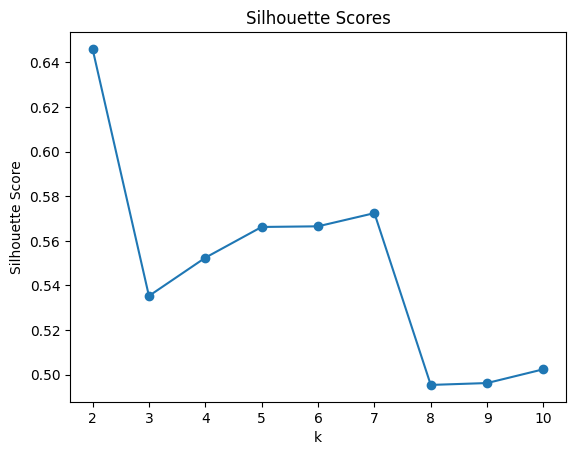

In [38]:
# Answer question 12 here and before question 13. Feel free to create extra cells.

plt.figure()

plt.plot(k_values, inertia_scores, marker='o')
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

plt.figure()

plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores")
plt.show()

16. Thinking of the elbox method and the plots, what is the optimal k? (text response)

*Answer question 13 here*

17. Once you've determined the optimal K (number of clusters), apply the clustering algorithms. Create new columns for the cluster values in df_sample.

In [39]:
# Answer question 14 here

optimal_k = 5 # Your code
X_sample_reduced = X_pca
# KMeans
kmeans = KMeans(n_clusters=optimal_k, random_state=1)
df_sample['KMeans Cluster'] = kmeans.fit_predict(X_sample_reduced)

# MiniBatchKMeans
# Use random_state=1
# n_clusters=optimal_k
minibatch_kmeans = MiniBatchKMeans(n_clusters=optimal_k, random_state=1)
df_sample['MiniBatchKMeans Cluster'] = minibatch_kmeans.fit_predict(X_sample_reduced)

# DBSCAN doesn't use something like n_clusters, feel free to read up on why
# (use eps=0.5 and min_samples=5)
dbscan = DBSCAN(eps=0.5, min_samples=5)
df_sample['DBSCAN Cluster'] = dbscan.fit_predict(X_sample_reduced)

# Gaussian Mixture Model
# Use random_state=1
# n_components=optimal_k
gmm = GaussianMixture(n_components=optimal_k, random_state=1)
df_sample['GMM Cluster'] = gmm.fit_predict(X_sample_reduced)

In [40]:
# Print and examine the data
# Run this cell

df_sample.head()

,Record ID,Agency Code,Agency Name,Agency Type,City,State,Year,Month,Incident,Crime Type,...,Perpetrator Ethnicity,Relationship,Weapon,Victim Count,Perpetrator Count,Record Source,KMeans Cluster,MiniBatchKMeans Cluster,DBSCAN Cluster,GMM Cluster
203598,203601,CODPD00,Denver,Municipal Police,Denver,Colorado,1990,October,4,Murder or Manslaughter,...,Unknown,Unknown,Knife,0,0,FBI,2,0,0,2
623071,623074,TXHPD00,Houston,Municipal Police,Harris,Texas,2012,September,12,Murder or Manslaughter,...,Unknown,Unknown,Unknown,0,0,FBI,0,3,0,0
557253,557256,MN02711,Minneapolis,Municipal Police,Hennepin,Minnesota,2009,July,3,Murder or Manslaughter,...,Unknown,Stranger,Blunt Object,0,1,FBI,0,3,0,0
448721,448724,WA01102,Pasco,Municipal Police,Franklin,Washington,2002,May,1,Murder or Manslaughter,...,Unknown,Unknown,Handgun,0,0,FBI,0,3,0,0
115639,115642,OH05702,Dayton,Municipal Police,Montgomery,Ohio,1985,July,5,Murder or Manslaughter,...,Not Hispanic,Stranger,Knife,0,0,FBI,2,4,0,2


18. For each of the 4 new columns (that stores a cluster ID for some algorithm), create a new dataframe that groups df_sample by Year and Cluster ID.

In [42]:
# Answer question 15 here

df_kmeans_grouped = df_sample.groupby(["Year", "KMeans Cluster"]).size().reset_index(name="Crime Count")

Print one of the new dataframes you created to see what it looks like and what the column names are. This will help with the next question.

In [43]:
# Your code here (not graded)

print(df_kmeans_grouped)

     Year  KMeans Cluster  Crime Count
0    1980               0            6
1    1980               1          147
2    1980               2         2113
3    1980               4           10
4    1981               0            3
..    ...             ...          ...
135  2013               4           11
136  2014               0         1241
137  2014               1          110
138  2014               3           82
139  2014               4            7

[140 rows x 3 columns]


19. For each new dataframe, plot the number of crimes per year per cluster. It could look something like this. Give each plot a title for easy differentiation
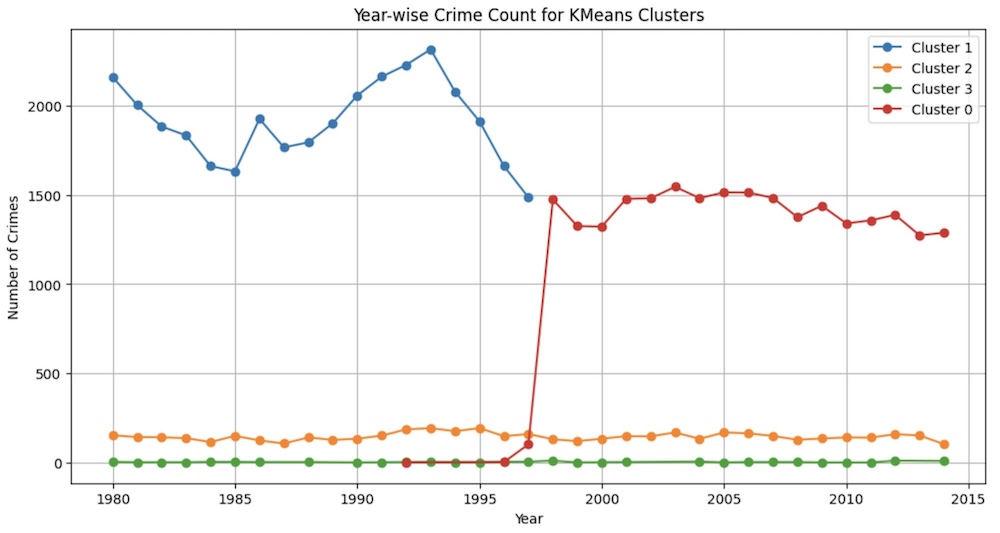

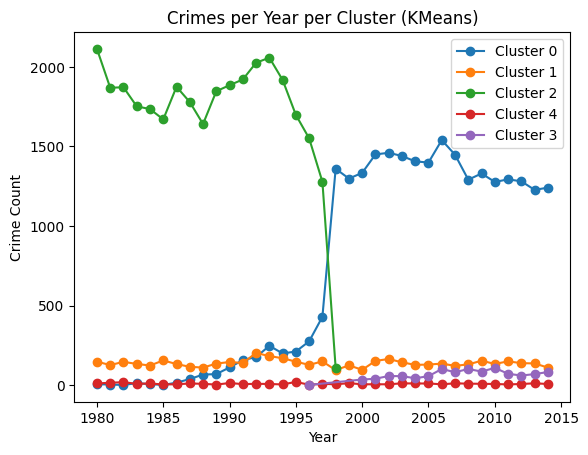

In [45]:
# Answer question 16 here and before Part 3. Feel free to create extra cells.

for cluster in df_kmeans_grouped["KMeans Cluster"].unique():
    cluster_data = df_kmeans_grouped[df_kmeans_grouped["KMeans Cluster"] == cluster]
    
    plt.plot(cluster_data["Year"], cluster_data["Crime Count"], marker='o', label=f"Cluster {cluster}")

plt.xlabel("Year")
plt.ylabel("Crime Count")
plt.title("Crimes per Year per Cluster (KMeans)")
plt.legend()
plt.show()

## Part 3. Feedback

1. Please share what you enjoyed and didn't enjoy about this assignment and how long it took for you to do it.

THis assignment was intuitive and taught me a lot about unsupervised learning and its uses, but it took me around 3 hours due to the research I had to do going into it and the methods surrounding it. 

2. What questions do you still have about the procedures we were following here and/or about the results?

I'm still not familiar with the intricate details of every clustering method, and more detail surrounding those would be helpful  in the near future. 

*Answer questions 1-2 here* (Answered above)

## Part 4. Submitting your work

### Congrats on finishing PA6!

*   Save this notebook (`File > Save`).
*   Download it to your computer as `.ipynb` (`File > Download > Download .ipynb`).
*   Submit the .ipynb file on Canvas.

Tips:
*   After finishing the work, click on the arrow to the right of "Run all" and then click on "Clear all outputs" and "Restart session." Then run each cell in order to make sure everything compiles.
*   Remember to delete the cells you created for testing and any Gemini-affected cells if you used help from Gemini.